# Procesamiento Digital de Imágenes - TP05: Dominio Frecuencial

**Objetivos de la guía:**

* Fijar los conceptos relacionados a la Transformada de Fourier bidimensional (TDF 2D) mediante su visualización.

* Comprender el proceso de filtrado en el dominio de la frecuencia.

* Aplicar filtros de acentuado en frecuencia y comprobar la ventaja computacional de la rutina FFT.




In [2]:
# Configuración Inicial
import cv2
import numpy as np
import matplotlib.pyplot as plt
import imutils # Para la rotación de imágenes solicitada en el Ejercicio 1 y 4
from ipywidgets import interact, IntSlider, FloatSlider
import ipywidgets as widgets
import helpers

def mostrar_img_y_espectro(img, dft_shift, titulo="Imagen"):
    """Función auxiliar para mostrar una imagen y su espectro de magnitud centrado"""
    # Calcular magnitud: 20 * log(magnitud) para poder visualizarla correctamente
    # dft_shift tiene 2 canales: real e imaginario
    magnitud = 20 * np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]) + 1)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].imshow(img, cmap='gray')
    axs[0].set_title(titulo)
    axs[0].axis('off')

    axs[1].imshow(magnitud, cmap='gray')
    axs[1].set_title('Espectro de Magnitud (TDF)')
    axs[1].axis('off')
    plt.show()

print("Entorno configurado. ¡Sube las imágenes de prueba (puente.jpg, ferrari-c.png, parrafo0.jpg)!")

Entorno configurado. ¡Sube las imágenes de prueba (puente.jpg, ferrari-c.png, parrafo0.jpg)!


## Ejercicio 1: Conceptos básicos de la TDF 2D

* Construiremos imágenes binarias simples para entender cómo se distribuye la energı́a en el dominio frecuencial.

* Verificaremos cómo la rotación en el dominio espacial afecta al dominio frecuencial



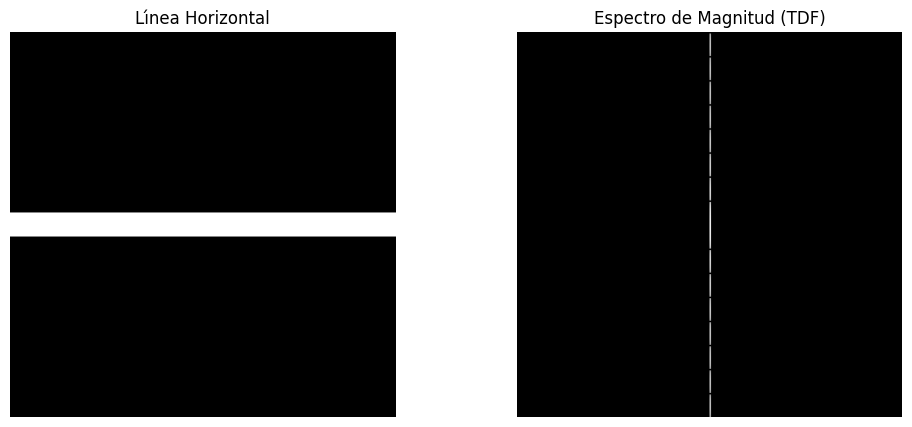

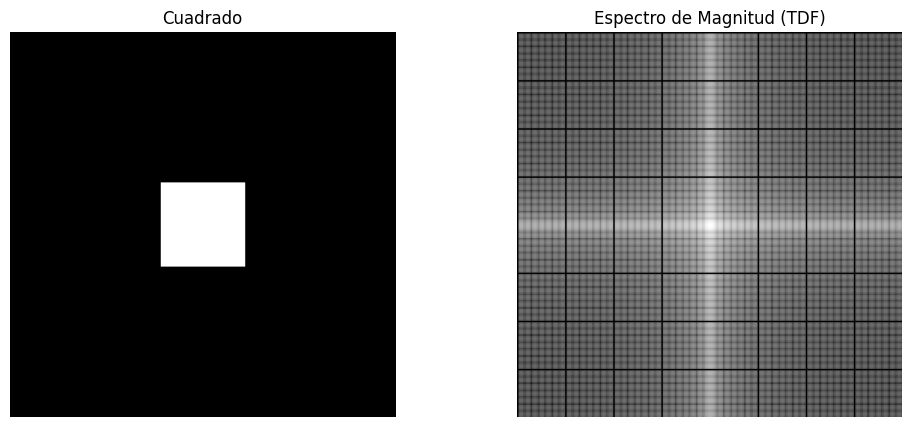

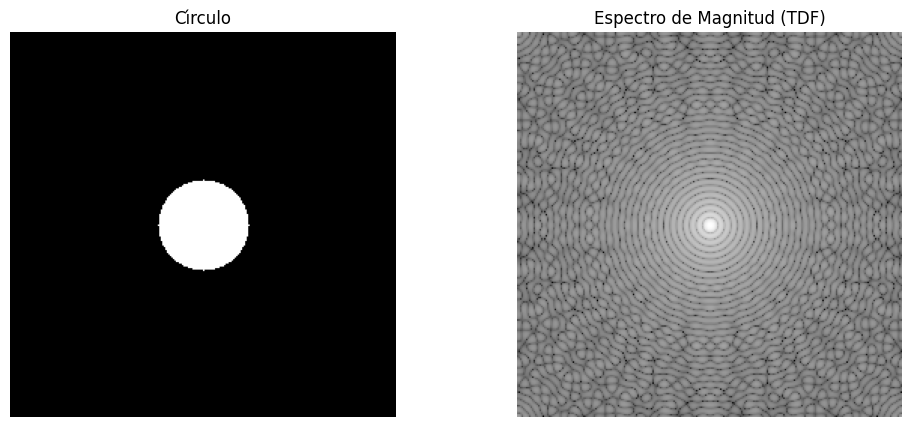

In [3]:
# Figuras Básicas y su TDF

def analizar_tdf_basica():
    # 1. Construir imágenes binarias de 256x256
    img_linea_h = np.zeros((256, 256), dtype=np.float32)
    img_linea_h[120:136, :] = 255 # Lı́nea horizontal gruesa

    img_cuadrado = np.zeros((256, 256), dtype=np.float32)
    img_cuadrado[100:156, 100:156] = 255 # Cuadrado centrado

    img_circulo = np.zeros((256, 256), dtype=np.float32)
    cv2.circle(img_circulo, (128, 128), 30, 255, -1) # Cı́rculo centrado

    imagenes = [("Lı́nea Horizontal", img_linea_h),
                ("Cuadrado", img_cuadrado),
                ("Cı́rculo", img_circulo)]

    for nombre, img in imagenes:
        # TODO: Calcular la TDF usando cv2.dft (recuerda usar el flag cv2.DFT_COMPLEX_OUTPUT)
        dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)

        # TODO: Centrar la TDF usando np.fft.fftshift
        dft_shift = np.fft.fftshift(dft)

        mostrar_img_y_espectro(img, dft_shift, titulo=nombre)

analizar_tdf_basica()

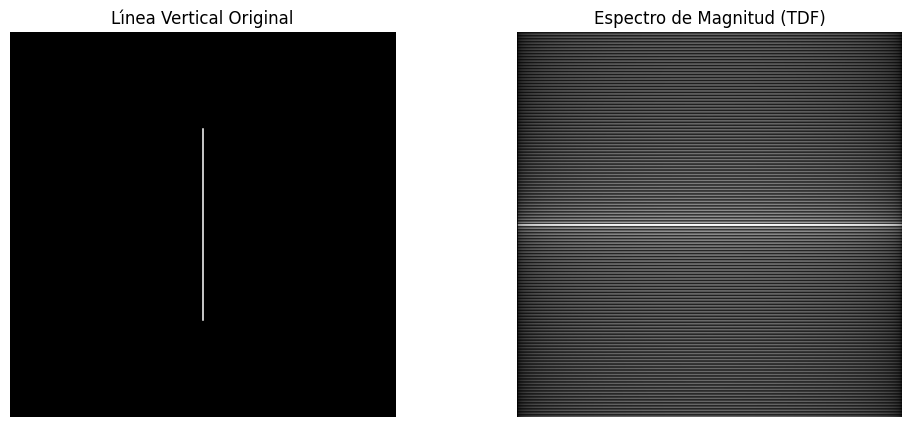

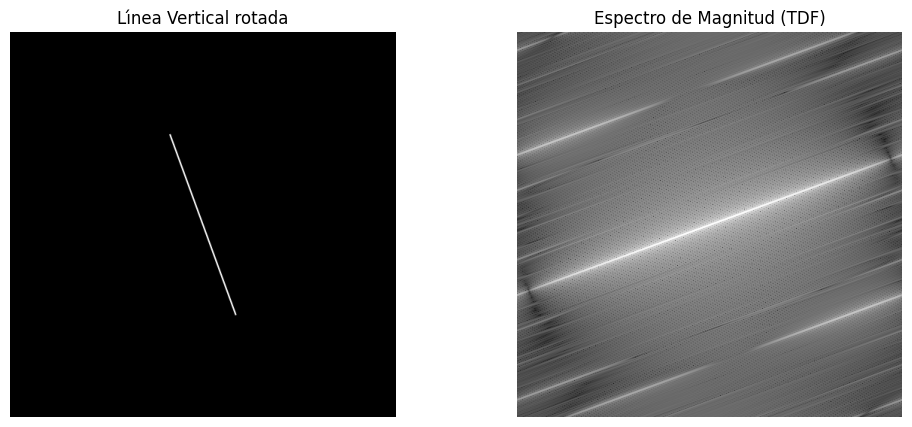

In [4]:
# Rotación y TDF
def analizar_rotacion():
    # Construir imagen de 512x512 con lı́nea vertical de 1px
    img = np.zeros((512, 512), dtype=np.float32)
    img[128:384, 255:257] = 255

    # TODO: Rotar la imagen 20 grados usando imutils.rotate
    img_rotada = imutils.rotate(img, angle=20)

    # TODO: Extraer una sección central de 256x256 de ambas imágenes
    sec_original = img[128:384, 128:384]
    sec_rotada = img_rotada[128:384, 128:384]

    # Calcular y mostrar TDF de la sección original
    dft_orig = cv2.dft(img, flags=cv2.DFT_COMPLEX_OUTPUT)
    mostrar_img_y_espectro(img, np.fft.fftshift(dft_orig), "Lı́nea Vertical Original")

    # Calcular y mostrar TDF de la sección rotada
    dft_rot = cv2.dft(img_rotada, flags=cv2.DFT_COMPLEX_OUTPUT)
    mostrar_img_y_espectro(img_rotada, np.fft.fftshift(dft_rot), "Lı́nea Vertical rotada")

analizar_rotacion()


**Reflexiona sobre lo que observas:**

* Al visualizar el espectro de la línea horizontal y la línea vertical, ¿qué relación notas entre la orientación geométrica del objeto en el dominio espacial y la distribución de la energía en el dominio de las frecuencias?

En el experimento de la rotación:
* compara la TDF de la imagen original con la TDF de la imagen rotada.
* ¿Qué le ocurre exactamente a la magnitud de la TDF cuando el objeto espacial gira?
* ¿Qué propiedad fundamental de la Transformada de Fourier se está comprobando aquí?

Las lineas horizontales tienen un espectro de frecuencias vertical pues es en esa dirección en donde se producen cambios bruscos. Si recorremos la imagen de forma horizontal, no habra cambios (frecuencia 0). La misma lógica se puede aplica a las lineas verticales.

En la rotación, lo que sucede es que la magnitud sufre una rotación exactamente igual y en el mismo sentido, esto coincide con la **propiedad de rotación de la transformada**.

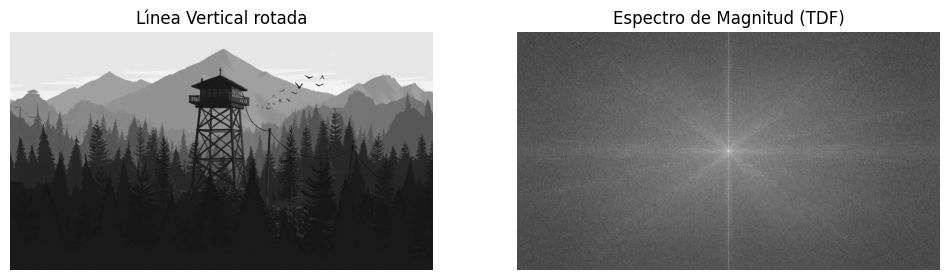

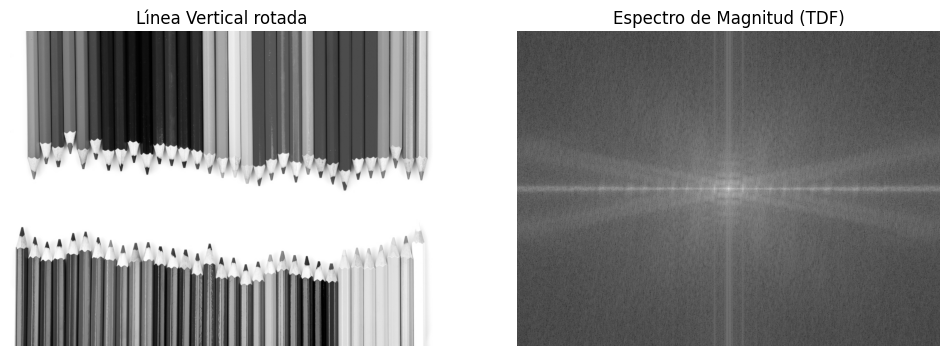

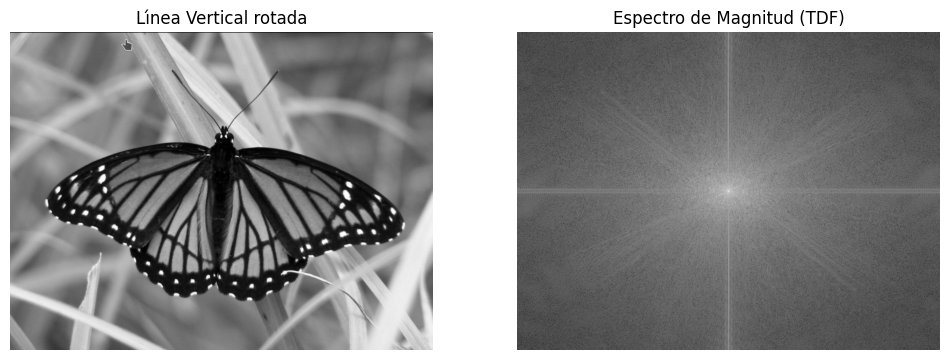

In [5]:
firewatch_img = cv2.imread('imagenes/firewatch.png', cv2.IMREAD_GRAYSCALE)
lapices_img = cv2.imread('imagenes/lapices02.jpg', cv2.IMREAD_GRAYSCALE)
mariposa_img = cv2.imread('imagenes/mariposa02.png', cv2.IMREAD_GRAYSCALE)

firewatch_rot = cv2.dft(np.float32(firewatch_img), flags=cv2.DFT_COMPLEX_OUTPUT)
mostrar_img_y_espectro(firewatch_img, np.fft.fftshift(firewatch_rot), "Lı́nea Vertical rotada")
lapices_rot = cv2.dft(np.float32(lapices_img), flags=cv2.DFT_COMPLEX_OUTPUT)
mostrar_img_y_espectro(lapices_img, np.fft.fftshift(lapices_rot), "Lı́nea Vertical rotada")
mariposa_rot = cv2.dft(np.float32(mariposa_img), flags=cv2.DFT_COMPLEX_OUTPUT)
mostrar_img_y_espectro(mariposa_img, np.fft.fftshift(mariposa_rot), "Lı́nea Vertical rotada")

## Ejercicio 2: Importancia de la Fase

Genere una imagen reconstruida solo con la magnitud considerando fase cero y otra usando solo fase y considerando magnitud unitaria

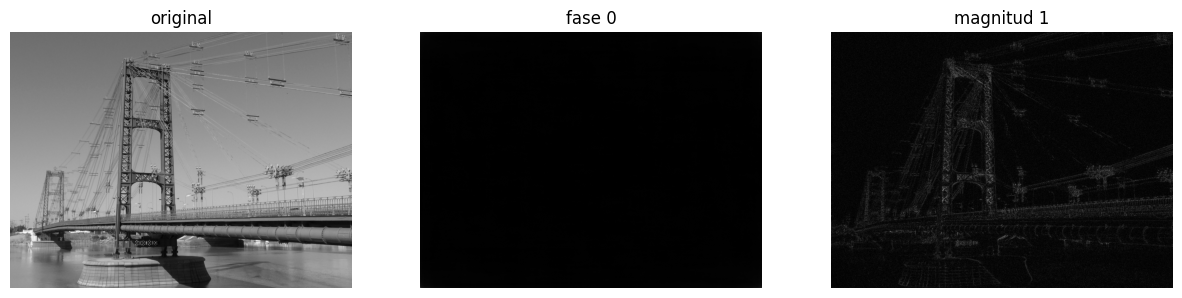

In [6]:
puente = cv2.imread('imagenes/puente.jpg', cv2.IMREAD_GRAYSCALE)

dft = np.fft.fft2(np.float32(puente))

mag, fase = np.abs(dft), np.angle(dft)

# sin fase
complejo_A = mag
img_A = np.abs(np.fft.ifft2(complejo_A))

# magnitud unitaria
complejo_B = 1 * np.exp(1j * fase)
img_B = np.abs(np.fft.ifft2(complejo_B))

fig, ax = plt.subplots(1, 3, figsize=(10, 10))
fig.set_figwidth(15)
ax[0].imshow(puente, cmap='gray'); ax[0].set_title("original")
ax[1].imshow(img_A, cmap='gray'); ax[1].set_title("fase 0")
ax[2].imshow(img_B, cmap='gray'); ax[2].set_title("magnitud 1")
for axs in ax.flat: axs.axis('off')
plt.show()

Reproduciremos el experimento de Oppenheim intercambiando la magnitud y la fase de dos imágenes distintas (***puente.jpg*** y ***ferrari-c.png***).

---

Recordemos que un número complejo se forma como:

$$\text{Magnitud} \cdot e^{j \cdot \text{Fase}}$$

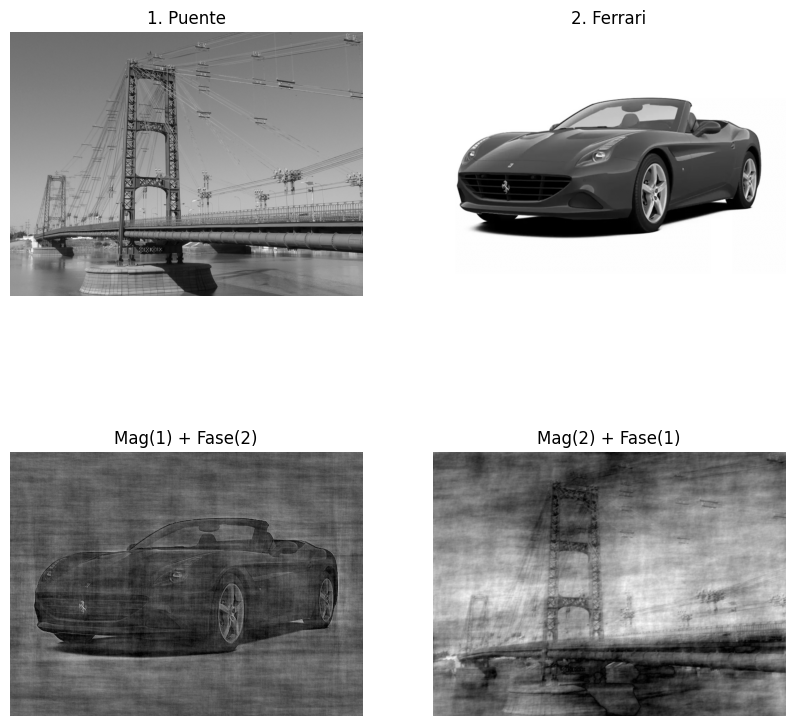

In [7]:
# Experimento de Oppenheim

def experimento_oppenheim(img1_path, img2_path):
    img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)

    if img1 is None or img2 is None: return "Cargar puente.jpg y ferrari-c.png"

    # Redimensionar para que tengan el mismo tamaño
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    # Calcular TDF de ambas imágenes (en numpy es más fácil manipular fase/magnitud)
    f1 = np.fft.fft2(img1)
    f2 = np.fft.fft2(img2)

    # Extraer Magnitud y Fase
    mag1, fase1 = np.abs(f1), np.angle(f1)
    mag2, fase2 = np.abs(f2), np.angle(f2)

    # Reconstruir Imagen A (Magnitud de IMG1 + Fase de IMG2)
    complejo_A = mag1 * np.exp(1j * fase2)
    img_A = np.abs(np.fft.ifft2(complejo_A))

    # Reconstruir Imagen B (Magnitud de IMG2 + Fase de IMG1)
    complejo_B = mag2 * np.exp(1j * fase1)
    img_B = np.abs(np.fft.ifft2(complejo_B))

    # Visualización
    fig, ax = plt.subplots(2, 2, figsize=(10, 10))
    ax[0][0].imshow(img1, cmap='gray'); ax[0][0].set_title("1. Puente")
    ax[0][1].imshow(img2, cmap='gray'); ax[0][1].set_title("2. Ferrari")
    ax[1][0].imshow(img_A, cmap='gray'); ax[1][0].set_title("Mag(1) + Fase(2)")
    ax[1][1].imshow(img_B, cmap='gray'); ax[1][1].set_title("Mag(2) + Fase(1)")
    for axs in ax.flat: axs.axis('off')
    plt.show()

# Ejecutar
experimento_oppenheim('imagenes/puente.jpg', 'imagenes/ferrari-c.png')


Se puede observar que la fase guarda la estructura geométrica de la imagen, por eso lo que podemos distinguir en cada mezcla es siempre la imagen a la cual corresponde la fase mezclada. En el caso en que anulemos la magnitud (magnitud unitaria en todo el plano), aún podeemos ver algunos de los detalles gracias a la fase, pero viceversa (magnitud real y fase cero).

## Ejercicio 3: Filtros Pasa-Bajos y Pasa-Altos

Diseñaremos filtros ideales y evaluaremos el fenómeno de Gibbs, y luego aplicaremos filtros gaussianos en el dominio frecuencial.

Usaremos un deslizador interactivo para variar la frecuencia de corte.


* **Implemente** las versiones Butterworth y Gaussianas indicadas en la guı́a.

In [ ]:
#  Filtro Pasa-Bajos Ideal Interactivo
img = cv2.imread('imagenes/puente.jpg', cv2.IMREAD_GRAYSCALE)
def actualizar(freq, orden, tam, sigma):
    filas, cols = img.shape
    crow, ccol = filas // 2, cols // 2

    # Crear máscara (Filtro Ideal Pasa-Bajos): Cı́rculo de 1s, resto 0s
    mask = np.zeros((filas, cols, 2), np.uint8)
    cv2.circle(mask, (ccol, crow), freq, (1, 1), -1)

    img_fideal = helpers.apply_pb_ideal(img, freq)
    img_fbutter = helpers.apply_pb_butterworth(img, freq, orden)
    img_fgauss = helpers.apply_pb_gaussiano(img, (tam,tam), sigma)

    fig, ax = plt.subplots(1, 4, figsize=(15, 10))
    ax[0].imshow(img, cmap='gray'); ax[0].set_title(f"Puente")
    ax[1].imshow(img_fideal, cmap='gray'); ax[1].set_title("Imagen Filtrada (Ideal)")
    ax[2].imshow(img_fbutter, cmap='gray'); ax[2].set_title("Imagen Filtrada (Butter)")
    ax[3].imshow(img_fgauss, cmap='gray'); ax[3].set_title("Imagen Filtrada (Gauss)")

    for axi in ax: axi.axis('off')
    plt.show();

# Interfaz interactiva para modificar la frecuencia de corte
interact(
    actualizar,
    freq=IntSlider(min=10, max=150, step=1, value=30),
    orden=IntSlider(min=1, max=10, step=1, value=1),
    tam=IntSlider(min=1, max=35, step=2, value=1),
    sigma=IntSlider(min=1, max=75, step=1, value=1)
);

interactive(children=(IntSlider(value=30, description='freq', max=150, min=10), IntSlider(value=1, description…

El filtro ideal produce el fenomeno de Gibbs ya que la forma de este en el dominio espacial es la de una funcion sinc en dos dimensiones (que tiene forma de onda). En el caso de los filtros Gaussianos y Butterworth, este fenomeno se elimina en gran medida gracias a que no tienen un corte abrupto, sino suave.

## Ejercicio 4: Filtrado Homomórfico

El filtrado homomórfico permite corregir la iluminación no uniforme modificando el contraste y acentuando detalles. La secuencia matemática es:

$$f(x,y) \xrightarrow{\ln} \mathcal{F} \xrightarrow{H(u,v)} \mathcal{F}^{-1} \xrightarrow{\exp} g(x,y)$$

In [ ]:
# Filtrado Homomórfico

def filtrado_homomorfico(img_path, gH=1.5, gL=0.5, D0=30, c=1.0):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return f"Carga la imagen '{img_path}'" [6]

    # 1. Transformación logarítmica (evitando log(0))
    img_log = np.log1p(np.float32(img))

    # 2. Cálculo de la TDF y centrado
    dft = cv2.dft(img_log, flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)

    # 3. Creación del Filtro Homomórfico H(u,v)
    filas, cols = img.shape
    crow, ccol = filas // 2, cols // 2
    U, V = np.meshgrid(np.arange(cols), np.arange(filas))
    D2 = (U - ccol)**2 + (V - crow)**2

    # Fórmula del filtro: H(u,v) = (gH - gL) * [1 - exp(-c * (D^2 / D0^2))] + gL
    H = (gH - gL) * (1 - np.exp(-c * (D2 / (D0**2 + 1e-5)))) + gL

    # Adaptar H para multiplicar con los 2 canales (real e imaginario) de la dft
    H = np.dstack((H, H))

    # 4. Filtrado en frecuencia: TDF(f) .* H
    dft_filtrada = dft_shift * H

    # 5. TDF Inversa
    f_ishift = np.fft.ifftshift(dft_filtrada)
    img_back = cv2.idft(f_ishift)
    img_back_mag = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])

    # 6. Exponencial: exp -> g(x,y)
    img_exp = np.expm1(img_back_mag)

    # Normalizar para visualización (0-255)
    img_homomorfica = cv2.normalize(img_exp, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    # --- Comparación con Ecualización Global ---
    img_ecualizada = cv2.equalizeHist(img)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs.imshow(img, cmap='gray'); axs.set_title("Original")
    axs[9].imshow(img_ecualizada, cmap='gray'); axs[9].set_title("Ecualización Pura")
    axs[10].imshow(img_homomorfica, cmap='gray'); axs[10].set_title(f"Homomórfico (gH={gH}, gL={gL})")
    for ax in axs: ax.axis('off')
    plt.show()

# Interfaz interactiva.
# TODO: Probar con 'casilla.tif' y 'reunion.tif' variando parámetros.
interact(filtrado_homomorfico,
         img_path=['casilla.tif', 'reunion.tif'],
         gH=FloatSlider(min=1.0, max=3.0, step=0.1, value=1.5),
         gL=FloatSlider(min=0.1, max=1.0, step=0.1, value=0.5),
         D0=IntSlider(min=10, max=100, step=10, value=30),
         c=FloatSlider(min=0.5, max=5.0, step=0.5, value=1.0))


**Reflexiona sobre lo que observas:**

 Piensa en el modelo fı́sico básico de formación de una imagen, donde un píxel es el producto de la iluminación por la reflectancia: $f(x,y)=i(x,y)⋅r(x,y)$.
La guía te pide seguir esta secuencia:

$$f(x,y)→ln→F→H(u,v)→F^{-1}→exp→g(x,y)$$

¿Por qué crees que el algoritmo nos obliga a aplicar un logaritmo natural ($ln$) antes de pasar a Fourier?

**Pista:** ¿Qué le hace la función logaritmo a una multiplicación y cómo esto nos facilita filtrar las bajas frecuencias (iluminación) por separado de las altas (detalles)?


## Ejercicio 5: Filtros de acentuado en el dominio frecuencial

Compararemos un filtro de Alta Potencia ($H_{AP}$) y un filtro de Énfasis de Alta Frecuencia ($H_{EAF}$) aplicados a la imagen **camaleon.tif**.


---

* Compare la imagen de alta potencia con la que se obtiene al aplicar  el filtro equivalente en el dominio espacial.


In [ ]:
# Filtros de Acentuado

def acentuado_frecuencial(A=1.5, a=0.5, b=2.0):
    img = cv2.imread('camaleon.tif', cv2.IMREAD_GRAYSCALE)
    if img is None: return "Carga 'camaleon.tif'"

    dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)

    # Crear un filtro Pasa-Altos (H_PA) ideal básico para la demostración
    filas, cols = img.shape
    crow, ccol = filas // 2, cols // 2
    mask_PB = np.zeros((filas, cols, 2), np.float32)
    cv2.circle(mask_PB, (ccol, crow), 30, (1, 1), -1)
    # Pasa-Altos = 1 - Pasa-Bajos
    H_PA = 1 - mask_PB

    # 1. Filtro de Alta Potencia: H_AP = (A - 1) + H_PA
    H_AP = (A - 1) + H_PA

    # 2. Filtro de Énfasis de Alta Frecuencia: H_EAF = a + b * H_PA
    H_EAF = a + b * H_PA

    # Aplicar filtros
    dft_AP = dft_shift * H_AP
    dft_EAF = dft_shift * H_EAF

    # Función auxiliar para IDFT
    def inversa(espectro):
        f_ishift = np.fft.ifftshift(espectro)
        img_back = cv2.idft(f_ishift)
        mag = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])
        return cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    img_AP = inversa(dft_AP)
    img_EAF = inversa(dft_EAF)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs.imshow(img, cmap='gray'); axs.set_title("Original")
    axs[9].imshow(img_AP, cmap='gray'); axs[9].set_title(f"Alta Potencia (A={A})")
    axs[10].imshow(img_EAF, cmap='gray'); axs[10].set_title(f"Énfasis AF (a={a}, b={b})")
    for ax in axs: ax.axis('off')
    plt.show()

interact(acentuado_frecuencial,
         A=FloatSlider(min=1.0, max=3.0, step=0.1, value=1.5),
         a=FloatSlider(min=0.1, max=2.0, step=0.1, value=0.5),
         b=FloatSlider(min=1.0, max=4.0, step=0.1, value=2.0))

**Reflexiona sobre lo que observas:**

Si aplicaras únicamente la máscara $H_{PA}$ (pasa-altos puro), la imagen se oscurecería perdiendo todo su color de fondo, dejando solo los bordes visibles.
Observa las fórmulas de Alta Potencia $H_{AP} =(A-1)+H_{PA}$ y Énfasis de Alta Frecuencia $H_{EAF} = a + b H_{PA}$


* ¿Qué logran aportar las constantes $A$, $a$ y $b$ a la imagen resultante?

* ¿Por qué la imagen realzada se sigue viendo "natural" (con su brillo base) a diferencia de lo que pasaría usando solo un filtro de bordes?

## Ejercicio 6.1: Rendimiento de FFT y agregado de ceros (Zero-Padding)

La transformada rápida (FFT) es mucho más eficiente cuando las dimensiones de la imagen son potencias de 2.

---

* OpenCV incluye la función **cv2.getOptimalDFTSize()** para determinar este tamaño.
* Agregaremos un borde de relleno (zero-padding) y mediremos el rendimiento.

---

**Reflexión**:

¿Qué efecto numérico (objetivo) y visual (subjetivo) produce el agregado de ceros?

In [ ]:
# FFT vs DFT
import timeit

def evaluar_rendimiento_fft(img_path='puente.jpg'):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return "Carga una imagen."

    filas, cols = img.shape
    print(f"Tamaño Original: {filas}x{cols}")

    # 1. Obtener tamaño óptimo para FFT
    Nopt = cv2.getOptimalDFTSize(filas)
    Mopt = cv2.getOptimalDFTSize(cols)
    print(f"Tamaño Óptimo (FFT): {Nopt}x{Mopt}")

    # 2. Generar imagen óptima (Padding)
    # TODO: Usa cv2.copyMakeBorder agregando ceros a la derecha y abajo
    img_opt = cv2.copyMakeBorder(img, 0, Nopt - filas, 0, Mopt - cols, cv2.BORDER_CONSTANT, value=0)

    # 3. Generar imagen (Óptima - 1)
    N_peor = Nopt - 1
    M_peor = Mopt - 1
    img_peor = cv2.copyMakeBorder(img, 0, max(0, N_peor - filas), 0, max(0, M_peor - cols), cv2.BORDER_CONSTANT, value=0)
    # Forzamos el recorte si era más grande
    img_peor = img_peor[:N_peor, :M_peor]

    # 4. Evaluar tiempos de ejecución
    def test_dft(imagen):
        cv2.dft(np.float32(imagen), flags=cv2.DFT_COMPLEX_OUTPUT)

    t_orig = timeit.timeit(lambda: test_dft(img), number=10)
    t_opt = timeit.timeit(lambda: test_dft(img_opt), number=10)
    t_peor = timeit.timeit(lambda: test_dft(img_peor), number=10)

    print("-" * 30)
    print(f"Tiempo Original ({filas}x{cols}): {t_orig:.4f} seg")
    print(f"Tiempo Óptimo   ({Nopt}x{Mopt}): {t_opt:.4f} seg")
    print(f"Tiempo Peor     ({N_peor}x{M_peor}): {t_peor:.4f} seg")

    # 5. Visualizar el efecto subjetivo de agregar ceros en el espectro
    dft_orig = np.fft.fftshift(cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT))
    dft_opt = np.fft.fftshift(cv2.dft(np.float32(img_opt), flags=cv2.DFT_COMPLEX_OUTPUT))

    mag_orig = 20 * np.log1p(cv2.magnitude(dft_orig[:,:,0], dft_orig[:,:,1]))
    mag_opt = 20 * np.log1p(cv2.magnitude(dft_opt[:,:,0], dft_opt[:,:,1]))

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs.imshow(mag_orig, cmap='gray'); axs.set_title("Espectro Original")
    axs[9].imshow(mag_opt, cmap='gray'); axs[9].set_title("Espectro con Zero-Padding")
    plt.show()


evaluar_rendimiento_fft('puente.jpg')

**Reflexiona sobre lo que observas:**

* **Efecto objetivo**: Analiza los tiempos arrojados por el script. ¿Por qué crees que llevar la imagen artificialmente al "tamaño óptimo" (rellenando con ceros) mejora drásticamente la velocidad del cálculo respecto a la imagen original?

* **Efecto subjetivo**: Al visualizar el espectro de la imagen rellenada con ceros (zero-padding), este parece verse con mayor nivel de detalle o "suavidad". ¿Realmente el padding le está inyectando nueva información frecuencial a la imagen, o qué es lo que verdaderamente estás viendo en esa TDF interpolada?

## Ejercicio 6.2: Trabajo de Aplicación - Preprocesamiento OCR

El objetivo es **identificar si un texto escaneado está rotado** y, de ser así, corregir su orientación automáticamente analizando el dominio de la frecuencia.

---
**Notas:**

* En el espectro de magnitud del texto, verás una lı́nea brillante ortogonal a las lı́neas de texto. Aquí puedes usar tu ingenio para detectar el ángulo de esta línea, puedes comenzar usando un umbral sobre la magnitud ...

* Puedes usar **imutils.rotate** o **cv2.warpAffine** para enderezar el texto original.



In [ ]:
#  Detección y Corrección de Rotación OCR

def corregir_rotacion_ocr(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return f"Error al cargar {img_path}"

    # PASO 1: Calcular la TDF de la imagen del texto
    dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    magnitud = 20 * np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]) + 1)
    magnitud = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    # PASO 2: Encontrar el ángulo de rotación
    # ...

    # -- TODO: Implementar la detección del ángulo --
    angulo_detectado = 0.0 # Reemplazar con lógica de Hough

    # PASO 3: Corregir la imagen
    # img_corregida = imutils.rotate(img, angle=angulo_detectado)
    img_corregida = img.copy()

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs.imshow(img, cmap='gray'); axs.set_title("Texto Original")
    axs[3].imshow(magnitud, cmap='gray'); axs[3].set_title("Espectro (Ver lı́nea ortogonal)")
    axs[9].imshow(img_corregida, cmap='gray'); axs[9].set_title(f"Corregida (Ang: {angulo_detectado})")
    for ax in axs: ax.axis('off')
    plt.show()

# Ejecutar la prueba
# corregir_rotacion_ocr('parrafo1.jpg')

**Reflexiona sobre lo que observas:**

* Repasemos: un texto escrito en párrafos tiene una estructura espacial muy marcada, líneas horizontales con espacios entre ellas. ¿Cómo se manifiesta esa direccionalidad en el espectro de magnitudes de la TDF?

* Si conoces la inclinación exacta de la energía en el dominio de las frecuencias, ¿cómo puedes utilizar esa información geométrica para calcular el ángulo necesario y enderezar automáticamente el documento, sin aplicar ningún algoritmo complejo que "lea" los caracteres?